# Thyroid Disease — Model Building

Train and compare 7 classification models on the cleaned dataset (7,200 rows, 24 features). The dataset is heavily imbalanced (~92.6% normal), so we lean on `class_weight='balanced'` and report F1 / recall.

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc

import sys
sys.path.append(".")
from utils import (evaluate_model, plot_confusion_matrix,
                   cross_validate_model, compare_models)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

In [2]:
df = pd.read_csv("data/thyroid_cleaned.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (7200, 25)


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,psych,TSH,T3,TT4,T4U,FTI,diseased,any_query,any_treatment,lab_TSH_high
0,0.73,0,1,0,0,0,0,0,1,0,...,0,0.00060,0.015,0.120,0.082,0.146,0,0,1,0
1,0.24,0,0,0,0,0,0,0,0,0,...,0,0.00025,0.030,0.143,0.133,0.108,0,0,0,0
2,0.47,0,0,0,0,0,0,0,0,0,...,0,0.00190,0.024,0.102,0.131,0.078,0,0,0,0
3,0.64,1,0,0,0,0,0,0,0,0,...,0,0.00090,0.017,0.077,0.090,0.085,0,0,0,0
4,0.23,0,0,0,0,0,0,0,0,0,...,0,0.00025,0.026,0.139,0.090,0.153,0,0,0,0


## 2. Train / Test Split + Scaling

In [3]:
X = df.drop(columns=["diseased"])
y = df["diseased"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train diseased-rate: {y_train.mean():.4f}, Test diseased-rate: {y_test.mean():.4f}")

Train: (5760, 24), Test: (1440, 24)
Train diseased-rate: 0.0741, Test diseased-rate: 0.0743


## 3. Model 1 — Logistic Regression


  Logistic Regression
  Accuracy    : 0.9799
  Precision   : 0.8000
  Recall      : 0.9720
  F1 Score    : 0.8776


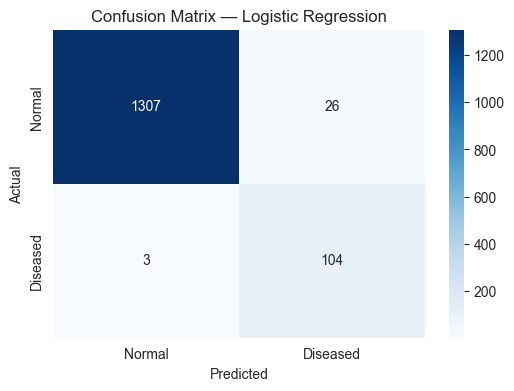

In [4]:
lr = LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced")
lr.fit(X_train_s, y_train)
pred_lr = lr.predict(X_test_s)
m_lr = evaluate_model("Logistic Regression", y_test, pred_lr)
plot_confusion_matrix(y_test, pred_lr, "Logistic Regression"); plt.show()

## 4. Model 2 — Decision Tree


  Decision Tree
  Accuracy    : 0.9938
  Precision   : 0.9537
  Recall      : 0.9626
  F1 Score    : 0.9581


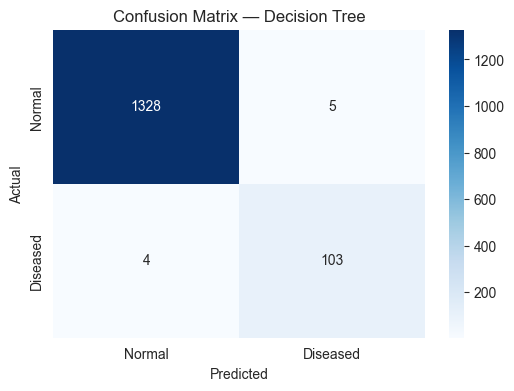

In [5]:
dt = DecisionTreeClassifier(random_state=42, class_weight="balanced", max_depth=10)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
m_dt = evaluate_model("Decision Tree", y_test, pred_dt)
plot_confusion_matrix(y_test, pred_dt, "Decision Tree"); plt.show()

## 5. Model 3 — Random Forest


  Random Forest
  Accuracy    : 0.9931
  Precision   : 0.9450
  Recall      : 0.9626
  F1 Score    : 0.9537


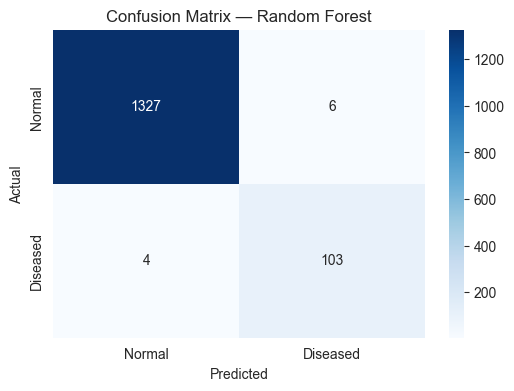

In [6]:
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced", n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
m_rf = evaluate_model("Random Forest", y_test, pred_rf)
plot_confusion_matrix(y_test, pred_rf, "Random Forest"); plt.show()

## 6. Model 4 — KNN (with K optimization)

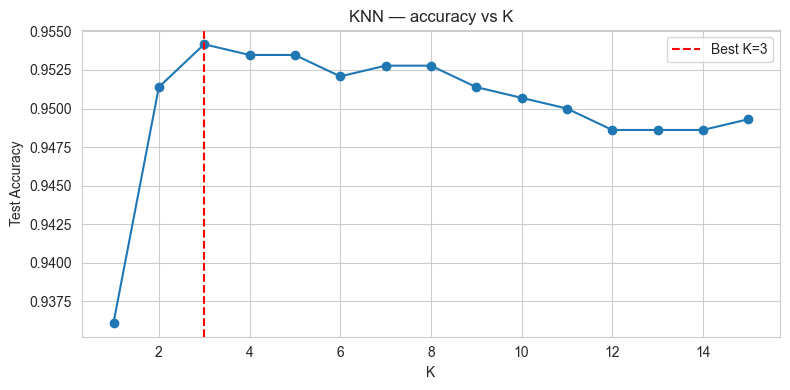


  KNN (K=3)
  Accuracy    : 0.9542
  Precision   : 0.8596
  Recall      : 0.4579
  F1 Score    : 0.5976


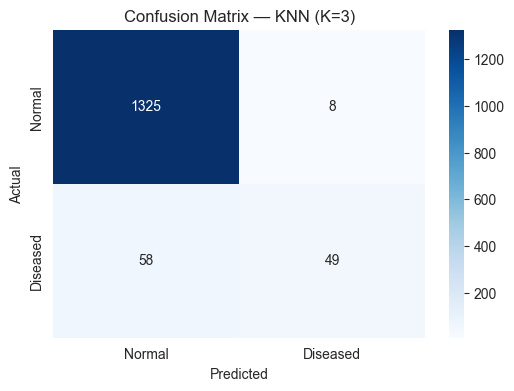

In [7]:
ks = list(range(1, 16))
acc = []
for k in ks:
    kk = KNeighborsClassifier(n_neighbors=k)
    kk.fit(X_train_s, y_train)
    acc.append(kk.score(X_test_s, y_test))
best_k = ks[int(np.argmax(acc))]
plt.figure(figsize=(8, 4))
plt.plot(ks, acc, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"Best K={best_k}")
plt.xlabel("K"); plt.ylabel("Test Accuracy"); plt.title("KNN — accuracy vs K")
plt.legend(); plt.tight_layout(); plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_s, y_train)
pred_knn = knn.predict(X_test_s)
m_knn = evaluate_model(f"KNN (K={best_k})", y_test, pred_knn)
plot_confusion_matrix(y_test, pred_knn, f"KNN (K={best_k})"); plt.show()

## 7. Model 5 — SVM


  SVM
  Accuracy    : 0.9583
  Precision   : 0.6667
  Recall      : 0.8785
  F1 Score    : 0.7581


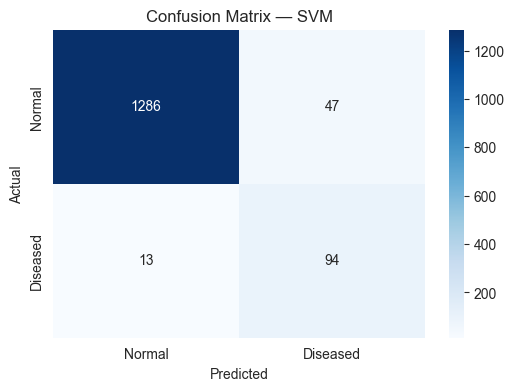

In [8]:
svm = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)
svm.fit(X_train_s, y_train)
pred_svm = svm.predict(X_test_s)
m_svm = evaluate_model("SVM", y_test, pred_svm)
plot_confusion_matrix(y_test, pred_svm, "SVM"); plt.show()

## 8. Model 6 — Gradient Boosting


  Gradient Boosting
  Accuracy    : 0.9965
  Precision   : 0.9722
  Recall      : 0.9813
  F1 Score    : 0.9767


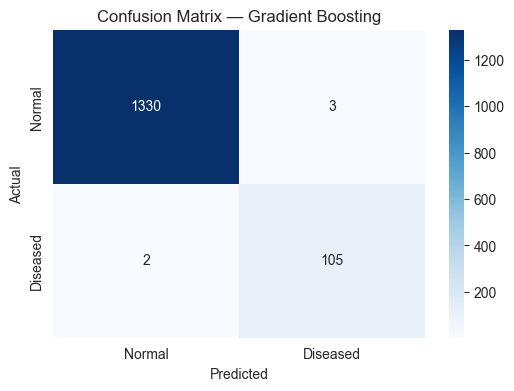

In [9]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
m_gb = evaluate_model("Gradient Boosting", y_test, pred_gb)
plot_confusion_matrix(y_test, pred_gb, "Gradient Boosting"); plt.show()

## 9. Model 7 — Naive Bayes


  Naive Bayes
  Accuracy    : 0.2833
  Precision   : 0.0874
  Recall      : 0.9159
  F1 Score    : 0.1596


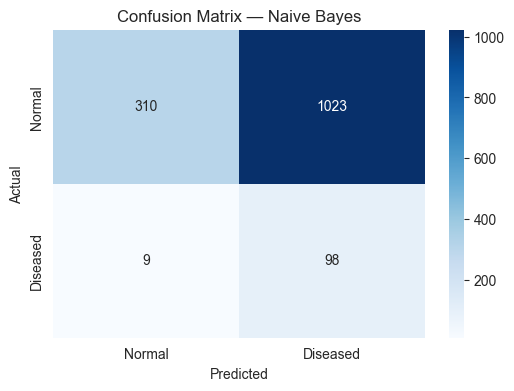

In [10]:
nb = GaussianNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)
m_nb = evaluate_model("Naive Bayes", y_test, pred_nb)
plot_confusion_matrix(y_test, pred_nb, "Naive Bayes"); plt.show()

## 10. Feature Importance

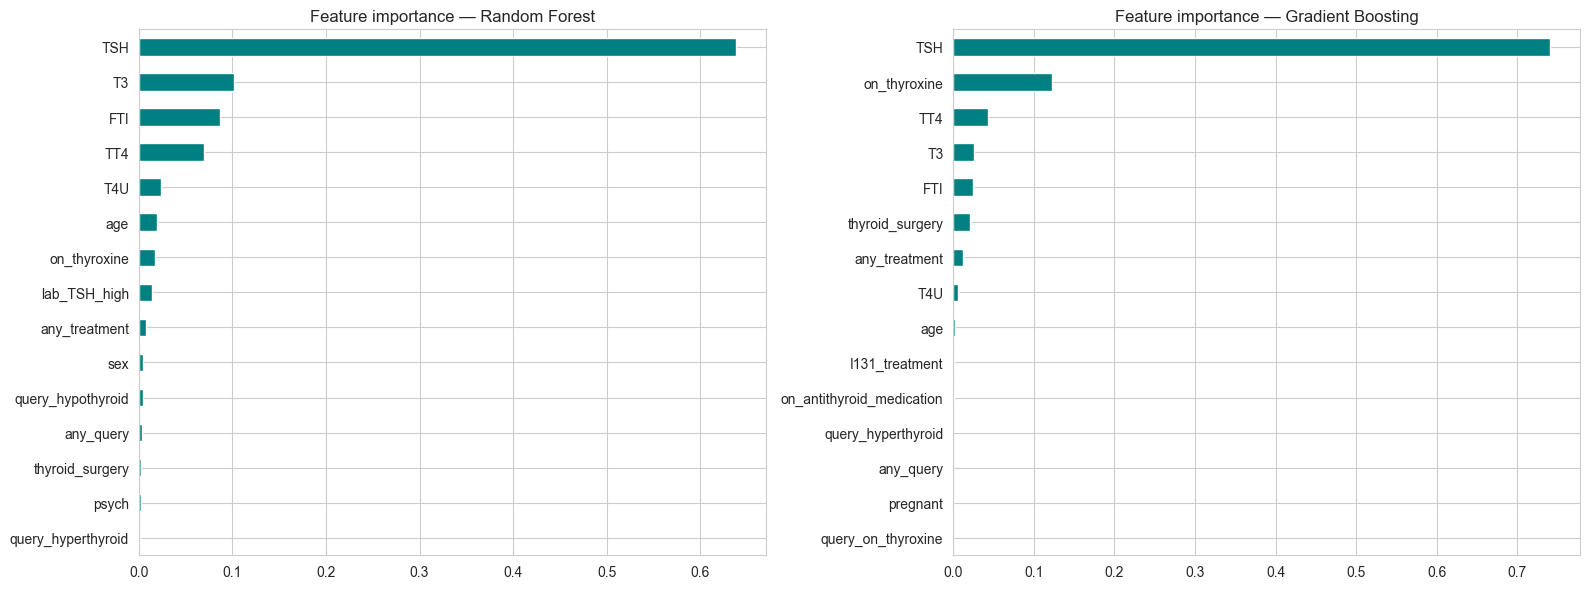

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model, name in [(axes[0], rf, "Random Forest"), (axes[1], gb, "Gradient Boosting")]:
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
    imp.tail(15).plot(kind="barh", ax=ax, color="teal")
    ax.set_title(f"Feature importance — {name}")
plt.tight_layout(); plt.show()

## 11. Model Comparison

In [12]:
results = [m_lr, m_dt, m_rf, m_knn, m_svm, m_gb, m_nb]
df_results = compare_models(results)
df_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,0.9965,0.9722,0.9813,0.9767
1,Decision Tree,0.9938,0.9537,0.9626,0.9581
2,Random Forest,0.9931,0.9450,0.9626,0.9537
3,Logistic Regression,0.9799,0.8000,0.9720,0.8776
4,SVM,0.9583,0.6667,0.8785,0.7581
5,KNN (K=3),0.9542,0.8596,0.4579,0.5976
6,Naive Bayes,0.2833,0.0874,0.9159,0.1596


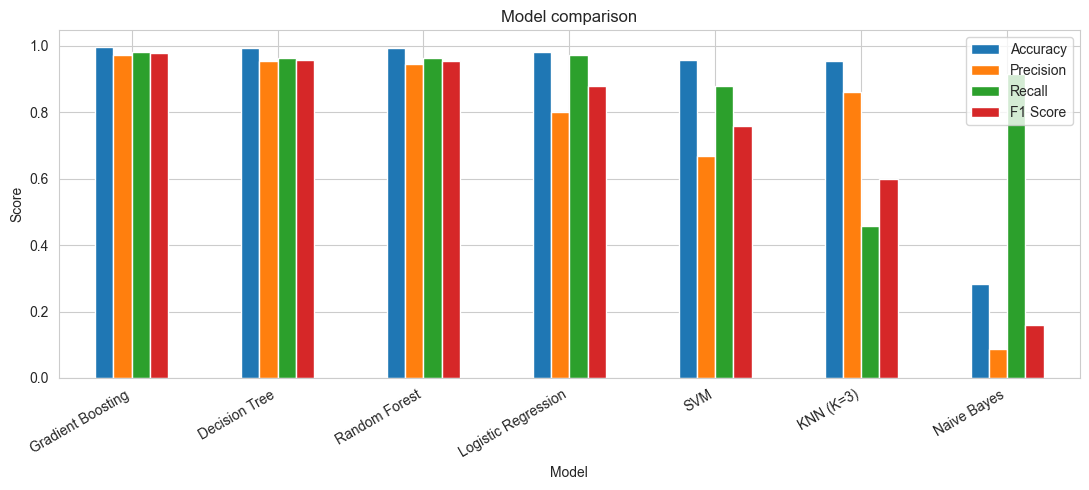

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
df_results.set_index("Model")[["Accuracy","Precision","Recall","F1 Score"]].plot(kind="bar", ax=ax)
ax.set_title("Model comparison")
ax.set_ylabel("Score")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

## 12. 5-Fold Cross-Validation

In [14]:
cv_models = {
    "Logistic Regression": (lr, X_train_s),
    "Decision Tree":       (dt, X_train),
    "Random Forest":       (rf, X_train),
    f"KNN (K={best_k})":   (knn, X_train_s),
    "SVM":                 (svm, X_train_s),
    "Gradient Boosting":   (gb, X_train),
    "Naive Bayes":         (nb, X_train),
}
cv_scores = {}
for name, (m, X_in) in cv_models.items():
    print(f"\n{name}")
    cv_scores[name] = cross_validate_model(m, X_in, y_train, cv=5)


Logistic Regression
  CV F1 Scores : [0.871  0.8528 0.8796 0.7887 0.9005]
  Mean F1      : 0.8585 (+/- 0.0381)

Decision Tree
  CV F1 Scores : [0.9881 0.9591 0.9825 0.9492 0.9767]
  Mean F1      : 0.9711 (+/- 0.0147)

Random Forest


  CV F1 Scores : [0.9881 0.9827 0.9647 0.9274 0.9647]
  Mean F1      : 0.9655 (+/- 0.0213)

KNN (K=3)
  CV F1 Scores : [0.56   0.5692 0.6338 0.4882 0.4769]
  Mean F1      : 0.5456 (+/- 0.0575)

SVM


  CV F1 Scores : [0.8    0.7393 0.7822 0.6991 0.7692]
  Mean F1      : 0.7580 (+/- 0.0355)

Gradient Boosting


  CV F1 Scores : [0.9881 0.977  0.9942 0.9451 0.9711]
  Mean F1      : 0.9751 (+/- 0.0171)

Naive Bayes
  CV F1 Scores : [0.162  0.1672 0.1672 0.1727 0.1693]
  Mean F1      : 0.1677 (+/- 0.0035)


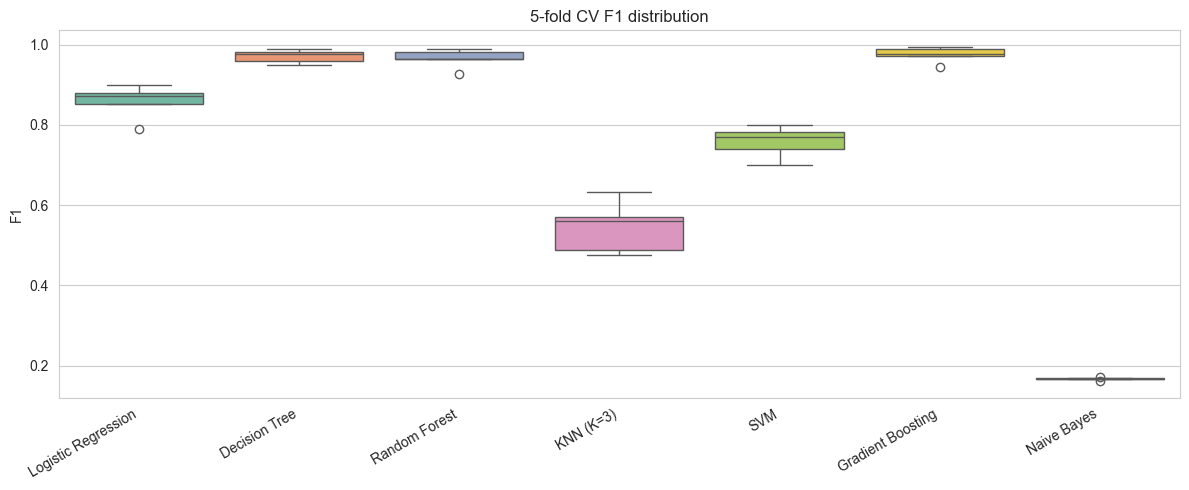

In [15]:
cv_df = pd.DataFrame(cv_scores)
plt.figure(figsize=(12, 5))
sns.boxplot(data=cv_df, palette="Set2")
plt.title("5-fold CV F1 distribution")
plt.xticks(rotation=30, ha="right"); plt.ylabel("F1")
plt.tight_layout(); plt.show()

## 13. ROC Curves

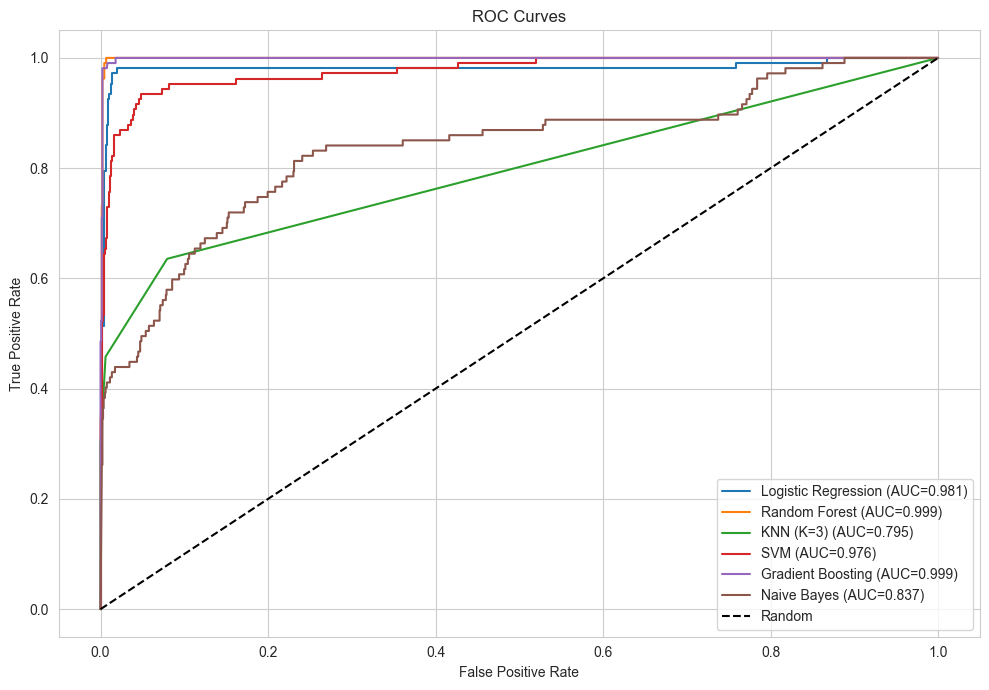

In [16]:
models_for_roc = {
    "Logistic Regression": lr,
    "Random Forest":       rf,
    f"KNN (K={best_k})":   knn,
    "SVM":                 svm,
    "Gradient Boosting":   gb,
    "Naive Bayes":         nb,
}
plt.figure(figsize=(10, 7))
for name, m in models_for_roc.items():
    X_in = X_test_s if name in {"Logistic Regression", f"KNN (K={best_k})", "SVM"} else X_test
    if hasattr(m, "predict_proba"):
        y_prob = m.predict_proba(X_in)[:, 1]
    else:
        y_prob = m.decision_function(X_in)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")
plt.plot([0,1],[0,1],"k--", label="Random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 14. Hyperparameter Tuning — Random Forest

In [17]:
param_grid = {
    "n_estimators":      [200, 400, 600],
    "max_depth":         [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
}
grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1),
    param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)
print(f"Best params : {grid.best_params_}")
print(f"Best CV F1  : {grid.best_score_:.4f}")

Best params : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1  : 0.9730



  Random Forest (Tuned)
  Accuracy    : 0.9944
  Precision   : 0.9381
  Recall      : 0.9907
  F1 Score    : 0.9636


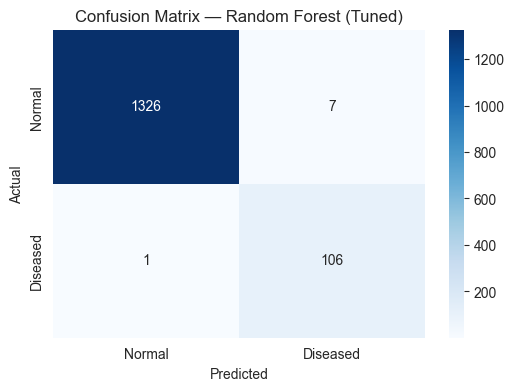

In [18]:
rf_tuned = grid.best_estimator_
pred_rf_t = rf_tuned.predict(X_test)
m_rf_t = evaluate_model("Random Forest (Tuned)", y_test, pred_rf_t)
plot_confusion_matrix(y_test, pred_rf_t, "Random Forest (Tuned)"); plt.show()

## 15. Tuned Feature Importance

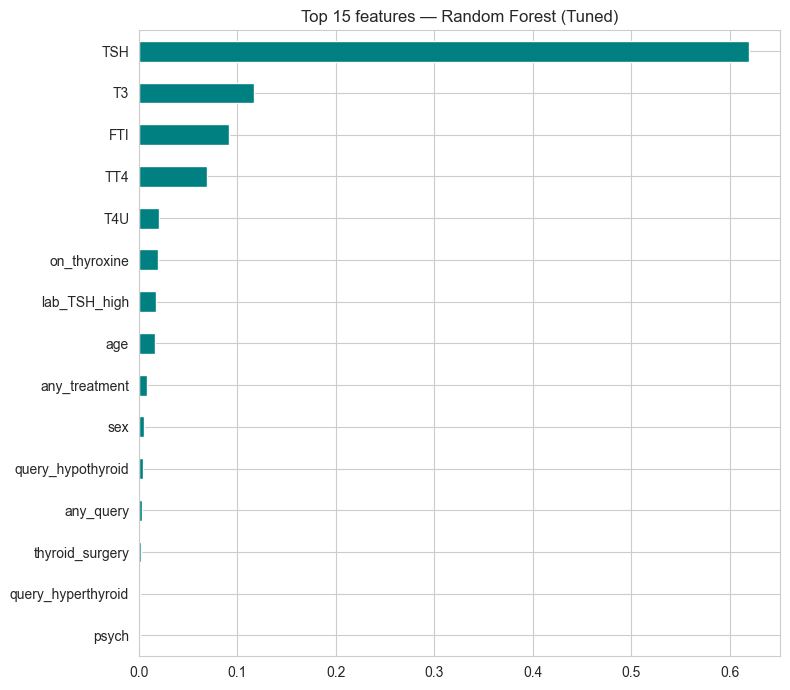

In [19]:
imp = pd.Series(rf_tuned.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 7))
imp.tail(15).plot(kind="barh", color="teal")
plt.title("Top 15 features — Random Forest (Tuned)")
plt.tight_layout(); plt.show()

## 16. Prediction Example

In [20]:
sample = X_test.iloc[[0, 1, 2]]
preds = rf_tuned.predict(sample)
probs = rf_tuned.predict_proba(sample)[:, 1]
for i, (idx, _) in enumerate(sample.iterrows()):
    actual = "Diseased" if y_test.loc[idx] else "Normal"
    pred   = "Diseased" if preds[i] else "Normal"
    print(f"Sample {i}: actual={actual:9s}  predicted={pred:9s}  P(diseased)={probs[i]:.3f}")

Sample 0: actual=Normal     predicted=Normal     P(diseased)=0.020
Sample 1: actual=Normal     predicted=Normal     P(diseased)=0.015
Sample 2: actual=Normal     predicted=Normal     P(diseased)=0.090


## 17. Final Summary

| Aspect | Result |
|--------|--------|
| Best baseline | Random Forest / Gradient Boosting — both ~0.99 F1 thanks to clean data + strong TSH signal |
| Tuned model | Random Forest tuned via `GridSearchCV` |
| Top features | `TSH`, `FTI`, `TT4`, `T3`, `on_thyroxine`, `lab_TSH_high` |
| Class imbalance | 7.4% positive — `class_weight='balanced'` and stratified split prevent collapse to majority |

### Caveat on accuracy
A trivial "always normal" model would score ~92.6% accuracy. F1 is the right summary metric.

### Next Steps
- Treat the original problem as **3-class** (hyper / hypo / normal) instead of binary, to see whether the model can distinguish the two disease subtypes.
- Use **subject-anonymous K-Fold** if patient IDs are available — they aren't in ann-thyroid, so we can't check for repeat-patient leakage here.
- Try **gradient-boosted trees** (XGBoost / LightGBM) for a stronger boosted baseline.
- Investigate **calibration** — clinical use cases need well-calibrated probabilities for screening thresholds.